# Telecom  Churn Prediction using Keras

In [1]:
# Telecom Churn Prediction (Deep Learning using Keras)

from google.colab import files
uploaded = files.upload()

Saving telecom_churn.csv to telecom_churn.csv


In [2]:
## Import Libraries and loading dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers

# load data
df = pd.read_csv("telecom_churn.csv")

# check data
print(df.head())

   index  Call Failure  Complaints  Subscription Length  Charge Amount  \
0      1             8           0                   38              0   
1      2             0           0                   39              0   
2      3            10           0                   37              0   
3      4            10           0                   38              0   
4      5             3           0                   38              0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2          

In [4]:
## Data Preprocessing

# target column
df["Churn"] = df["Churn"].astype(int)

# separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]


## Train-Test Split and Scaling


# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
## Build Neural Network Model and training the Model

# build keras model
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.7812 - loss: 0.6148 - val_accuracy: 0.7500 - val_loss: 0.6708
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8125 - loss: 0.6063 - val_accuracy: 0.7500 - val_loss: 0.6640
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8281 - loss: 0.5977 - val_accuracy: 0.7500 - val_loss: 0.6572
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8281 - loss: 0.5891 - val_accuracy: 0.7500 - val_loss: 0.6506
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8281 - loss: 0.5816 - val_accuracy: 0.7500 - val_loss: 0.6441
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8281 - loss: 0.5731 - val_accuracy: 0.7500 - val_loss: 0.6378
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8281 - loss: 0.5653 - val_accuracy: 0.7500 - val_loss: 0.6315
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8281 - loss: 0.5579 - val_accuracy: 0.7500 - val_loss: 0.6255
Epoch 9/

In [6]:
## Model Evaluation

loss, accuracy = model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", accuracy)

# predictions
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8500 - loss: 0.4285
Test Accuracy: 0.8500000238418579
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20


Confusion Matrix:
 [[17  0]
 [ 3  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


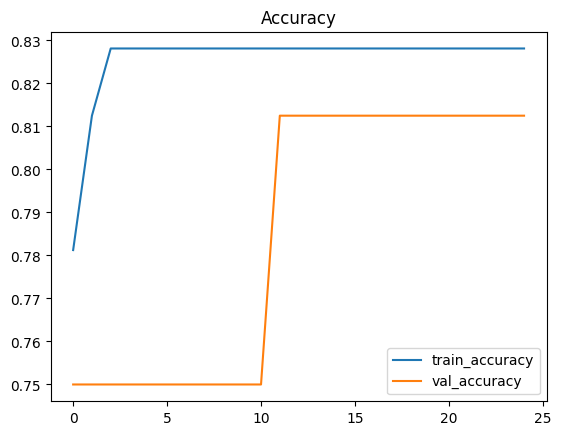

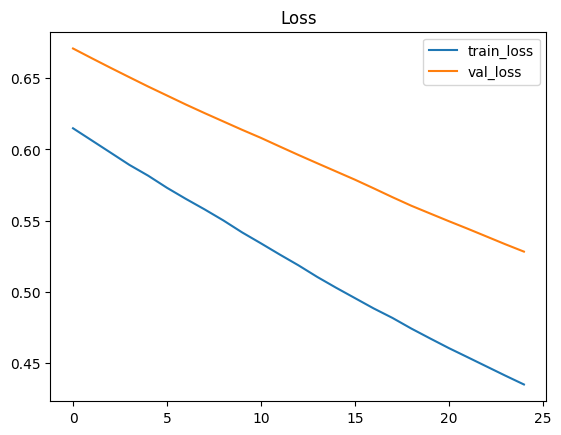

In [7]:
## Visualization of Results

# plots
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.title("Accuracy")
plt.savefig("accuracy.png")
plt.show()

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.savefig("loss.png")
plt.show()